# Assignment

**Task 1:** Load the MNIST dataset. Split it into training, validation, and test sets. Apply PCA to reduce dimensionality.

In [1]:
from sklearn.model_selection import train_test_split
from sklearn.datasets import fetch_openml
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.metrics import accuracy_score
import numpy as np

from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import plotly.express as px

Loading the MNIST dataset. Splitting it into training, validation, and test sets

In [2]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml('mnist_784', version=1, cache=True)

X = mnist["data"]
y = mnist["target"].astype(np.uint8)

X_train = X[:50000]
y_train = y[:50000]

X_test = X[60000:]
y_test = y[60000:]

X_val = X[50000:60000]
y_val = y[50000:60000]

C:\Users\User\venv\lib\site-packages\sklearn\datasets\_openml.py:1022: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [3]:
mnist_df = pd.DataFrame(X_train)
mnist_df['label'] = y_train
mnist_df.head(10)

C:\Users\User\AppData\Local\Temp\ipykernel_10192\3860699747.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  mnist_df['label'] = y_train


,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,pixel10,...,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784,label
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


A bit of data visualization

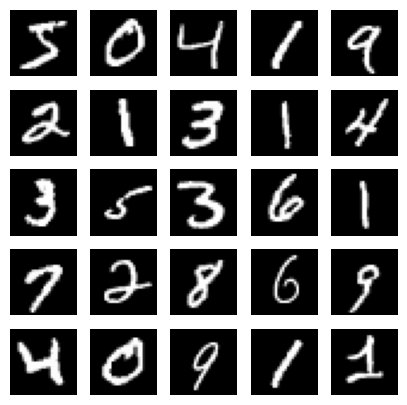

In [4]:
def plot_digits(data, images_per_row=10, n_images=25):
    images = data.values.reshape(-1, 28, 28)
    plt.figure(figsize=(images_per_row, images_per_row))
    
    for idx in range(n_images):
        plt.subplot(n_images // images_per_row, images_per_row, idx + 1)
        plt.imshow(images[idx], cmap='gray')
        plt.axis('off')

plot_digits(X_train, images_per_row=5, n_images=25)
plt.show()

## PCA

In [5]:
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print(f"Components count after PCA: {pca.n_components_}")

Components count after PCA: 154


**Task 2:** Cluster the dataset using K-Means. Determine the optimal number of clusters.

K-means clustering is an unsupervised learning algorithm used for data clustering, which groups unlabeled data points into groups or clusters. K-means is an iterative, centroid-based clustering algorithm that partitions a dataset into similar groups based on the distance between their centroids. The centroid, or cluster center, is either the mean or median of all the points within the cluster depending on the characteristics of the data.

How to determine the optimal number of clusters?
- **Elbow Method (Inertia-based)** \
This method calculates the inertia (within-cluster sum of squared distances) for different values of k (number of clusters).
The optimal k is the "elbow point," where the rate of decrease in inertia slows down significantly.
- **Silhouette Analysis** \
This method calculates the silhouette coefficient, which measures how well data points fit within their cluster vs. how far they are from other clusters. The silhouette score ranges from -1 to 1, where a higher score indicates better clustering. The optimal **k is the one that maximizes** the silhouette score.

## Elbow Method

In [6]:
inertia = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42,  n_init=10)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

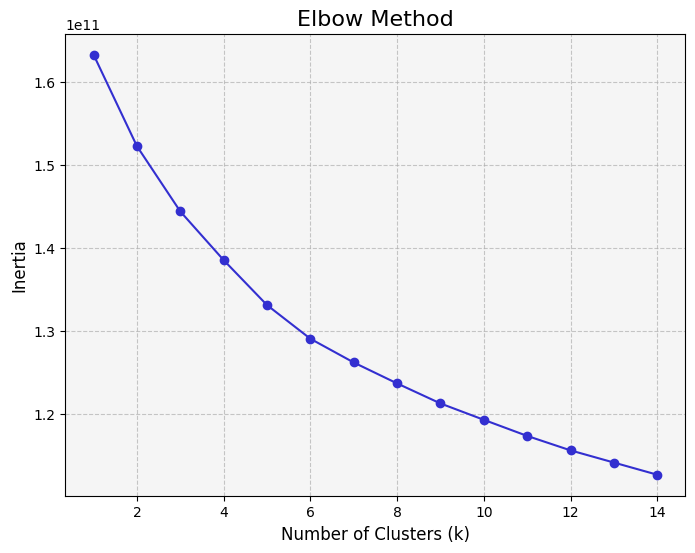

In [7]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.set_facecolor('whitesmoke')
ax.plot(k_range, inertia, marker='o', color='#332FD0')
ax.set_title('Elbow Method', fontsize=16)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Inertia', fontsize=12)
ax.grid(linestyle='--', alpha=0.7)

## Conclusions from the Graph:

From the Elbow Method graph, it is not immediately obvious what the optimal number of clusters should be. However, a reasonable estimation **lies between 6 and 8 clusters**.\
The key insight here is to look for the point at which the inertia (within-cluster sum of squared distances) starts to decrease at a significantly slower rate, indicating diminishing returns in reducing intra-cluster variation by adding more clusters. This point of diminishing returns represents the "elbow," which suggests the ideal number of clusters.

## Silhouette Analysis

In [8]:
silhouette_scores = []

for k in range(2, 15): 
    kmeans = KMeans(n_clusters=k, random_state=42,  n_init=10)
    cluster_labels = kmeans.fit_predict(X_pca)
    silhouette_avg = silhouette_score(X_pca, cluster_labels)
    silhouette_scores.append(silhouette_avg)

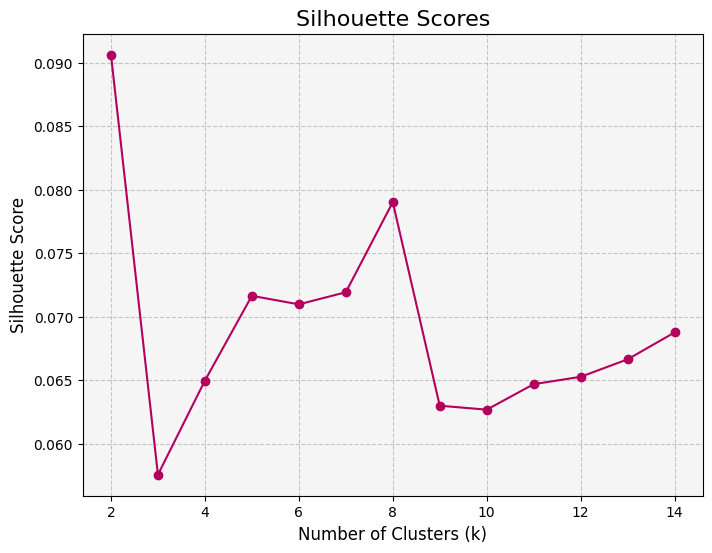

In [9]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.set_facecolor('whitesmoke')
ax.plot(range(2, 15), silhouette_scores, marker='o', color='#B3005E')
ax.set_title('Silhouette Scores', fontsize=16)
ax.set_xlabel('Number of Clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.grid(linestyle='--', alpha=0.7)

## Results!

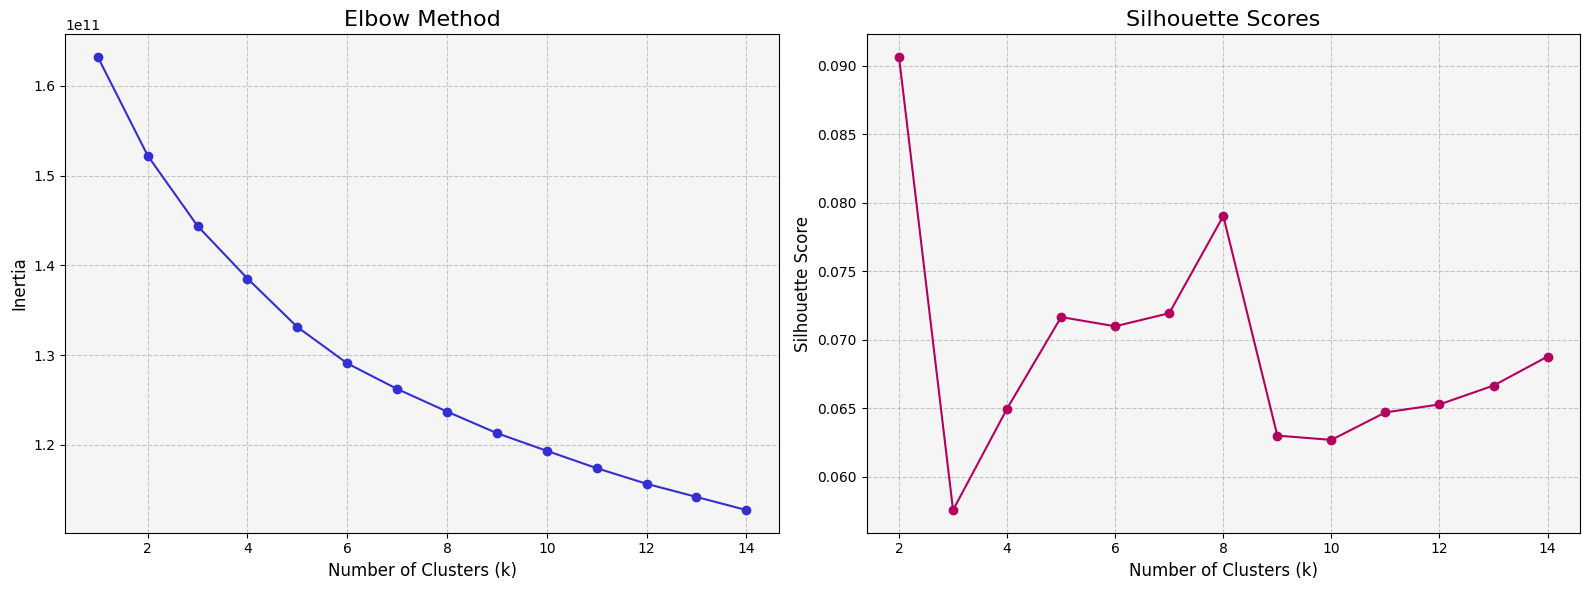

In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.set_facecolor('whitesmoke')
ax1.plot(k_range, inertia, marker='o', color='#332FD0')
ax1.set_title('Elbow Method', fontsize=16)
ax1.set_xlabel('Number of Clusters (k)', fontsize=12)
ax1.set_ylabel('Inertia', fontsize=12)
ax1.grid(linestyle='--', alpha=0.7)

ax2.set_facecolor('whitesmoke')
ax2.plot(range(2, 15), silhouette_scores, marker='o', color='#B3005E')
ax2.set_title('Silhouette Scores', fontsize=16)
ax2.set_xlabel('Number of Clusters (k)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.grid(linestyle='--', alpha=0.7)

plt.tight_layout()

## Conclusions from the Graph:

From the graph, we can see that **the silhouette score is highest at k = 8**. This means that dividing the data into 8 clusters provides the best balance between cluster separation and cohesion. Therefore, **k = 8** is the most suitable choice for the number of clusters.

Next, I want to visualize the clustering results for \( k = 8 \) clusters on a 2D graph. To achieve this, I need to further reduce the dimensionality of the data (already reduced using PCA) down to **2 dimensions**, making it suitable for plotting on a 2D graph.

- **First step**: I apply PCA again, but this time with `n_components=2`, to reduce the data to 2D while retaining as much structure as possible for visualization purposes.
- **Second step**: Using the optimal number of clusters (\( k = 8 \)), I perform clustering again with **K-Means** and predict the cluster labels for the 2D data. These cluster labels will be used to assign colors to the data points in the graph, making the clustering structure visually clear.


In [11]:
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_pca)

In [12]:
optimal_k = 8
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
cluster_labels = kmeans.fit_predict(X_pca)

C:\Users\User\venv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


In [13]:
df = pd.DataFrame(X_pca_2d, columns=["PCA Dimension 1", "PCA Dimension 2"])
df["Cluster"] = cluster_labels

In [14]:
df

,PCA Dimension 1,PCA Dimension 2,Cluster
0,118.147994,-319.129332,3
1,1003.942601,-320.413038,0
2,-52.149313,396.292968,2
3,-806.002059,-587.787692,4
4,-369.327432,735.197983,5
...,...,...,...
49995,293.852205,-505.124967,1
49996,362.587750,-64.682378,0
49997,-364.815746,-501.222680,1
49998,-385.901140,262.478086,2


## Final Visualisation! ✌🏼

In [15]:
colors = [
    "#6A0572", 
    "#AB47BC", 
    "#C2185B",
    "#E91E63",  
    "#FF4081",  
    "#F8BBD0", 
    "#BA68C8", 
    "#7B1FA2"
]

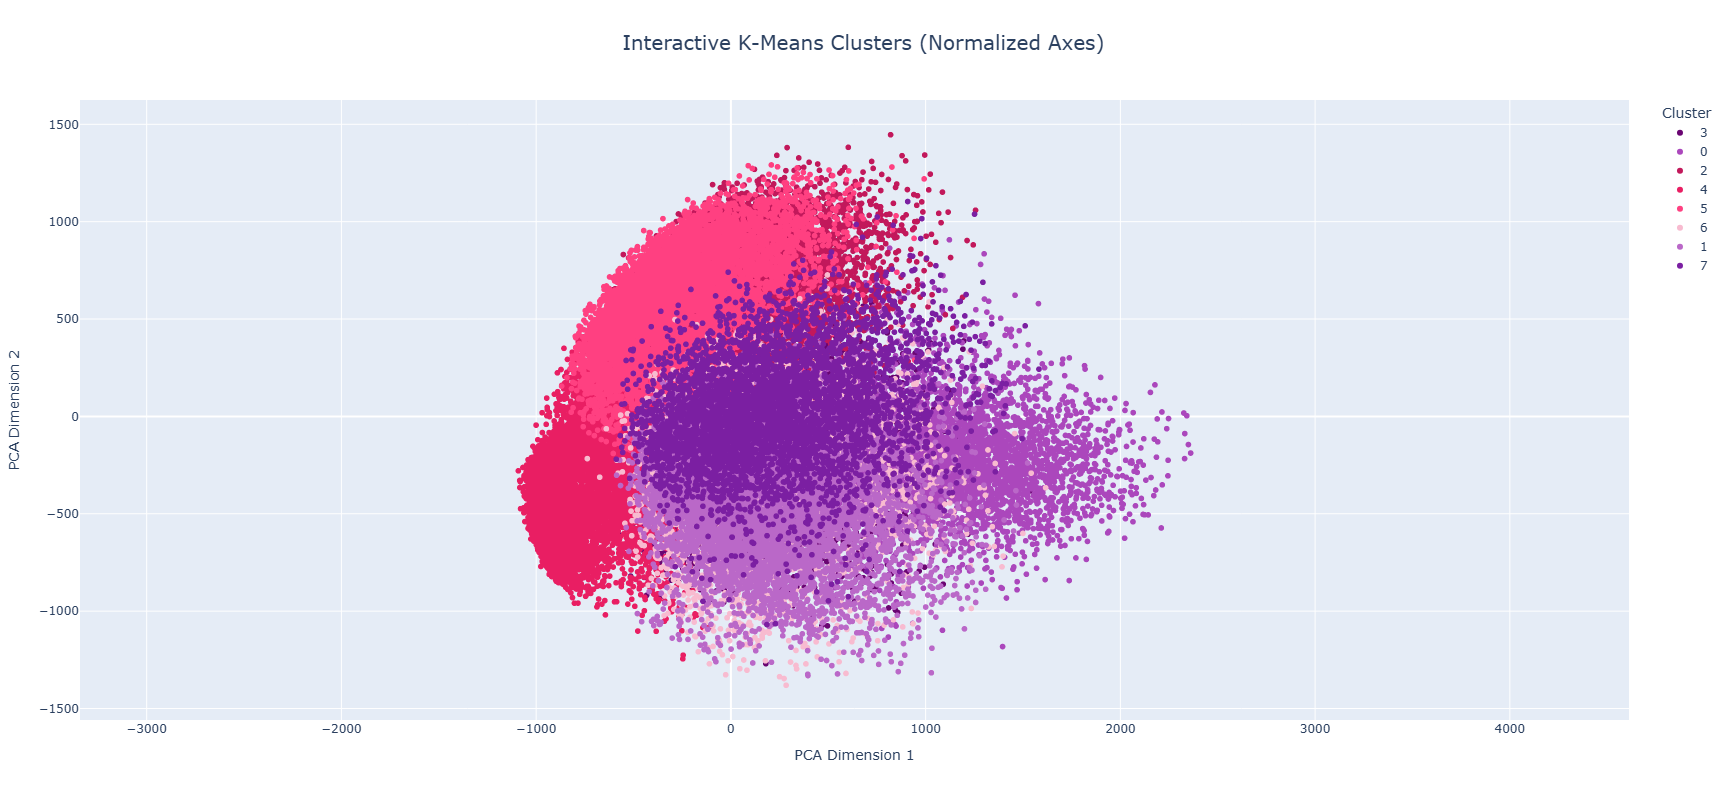

In [17]:
fig = px.scatter(
    df,
    x="PCA Dimension 1",
    y="PCA Dimension 2",
    color=df["Cluster"].astype(str),
    title="Interactive K-Means Clusters (Normalized Axes)",
    color_discrete_sequence=colors,
    labels={"color": "Cluster"}
)

fig.update_layout(    
    title=dict(
    text="Interactive K-Means Clusters (Normalized Axes)",
    x=0.5,
    font=dict(size=20)),
    xaxis=dict(scaleanchor="y", scaleratio=1),
    yaxis=dict(scaleanchor="x", scaleratio=1),
    width=1200,  
    height=800, 
    dragmode="pan",
)

fig.show()

# P. s.

You must run the code that generates the graph because I used an interactive library (https://plotly.com/python/) for this purpose, making it more convenient. \
This way, by hovering over a point, I can see its value and the cluster it belongs to. Additionally, I can drag and zoom the graph. Therefore, I have also included the output as a screenshot here for reference.

Output:

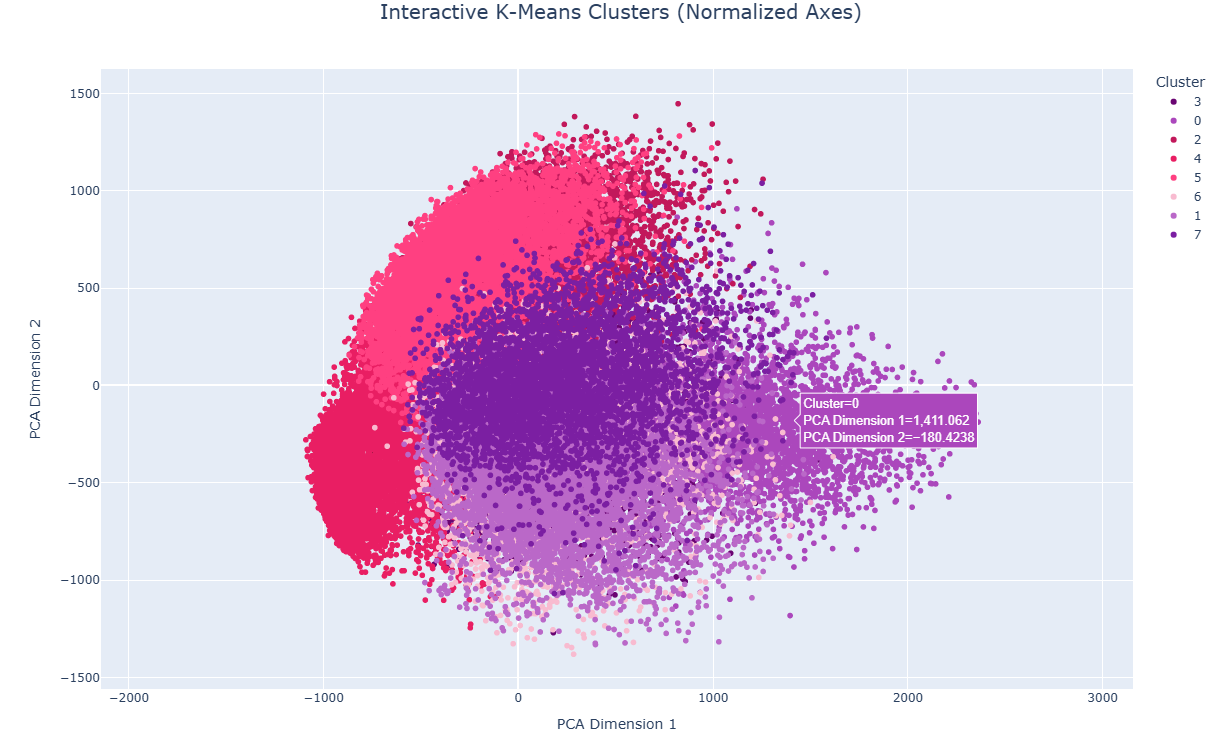

## Thanks for reading! 🎀